Does the first product photo type influence customer engagement?

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path 


In [2]:
data_path = Path("../data/processed/session_summary.csv")

if not data_path.exists():
    raise FileNotFoundError(
        f"Session dataset not found at: {data_path.resolve()}"
    )

session_df = pd.read_csv(data_path)

print(f"Rows: {session_df.shape[0]:,}")
print(f"Columns: {session_df.shape[1]}")

Rows: 24,026
Columns: 16


In [9]:
photo_summary = (
    session_df.groupby("first_photo_name")
    .agg(
        sessions=("session_id", "count"),
        mean_clicks=("click_count", "mean"),
        median_clicks=("click_count", "median"),
        q1_clicks=("click_count", lambda x: x.quantile(0.25)),
        q3_clicks=("click_count", lambda x: x.quantile(0.75)),
        max_clicks=("click_count", "max")
    )
)

photo_summary.round(2)

,sessions,mean_clicks,median_clicks,q1_clicks,q3_clicks,max_clicks
first_photo_name,,,,,,
Front View,18619,7.05,4.0,2.0,9.0,195
Profile View,5407,6.33,4.0,2.0,8.0,112


Sessions beginning with a Front View product image showed slightly higher average engagement (7.05 vs. 6.33 clicks per session).

However, the median engagement was identical for both groups (4 clicks), indicating that the typical browsing behaviour is similar regardless of photo type.

The higher mean for Front View appears to be driven by more highly engaged sessions in the upper tail of the distribution rather than by a general shift across all users.

Statistical testing is required to determine whether these observed differences are larger than would be expected by chance.

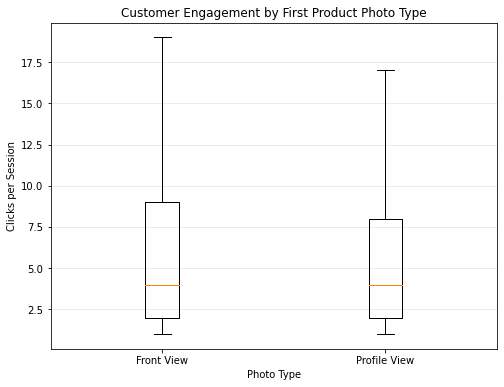

In [10]:
plt.figure(figsize=(8,6))

plt.boxplot(
    [
        session_df.loc[
            session_df["first_photo_name"]=="Front View",
            "click_count"
        ],
        session_df.loc[
            session_df["first_photo_name"]=="Profile View",
            "click_count"
        ]
    ],
    labels=["Front View","Profile View"],
    showfliers=False
)

plt.title("Customer Engagement by First Product Photo Type")
plt.xlabel("Photo Type")
plt.ylabel("Clicks per Session")

plt.grid(axis="y", alpha=0.3)

plt.show()

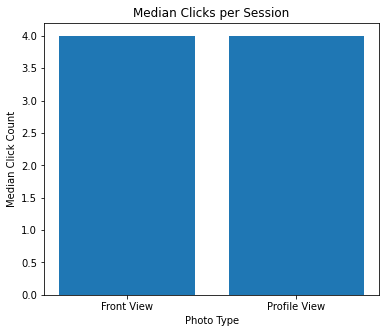

In [11]:
plt.figure(figsize=(6,5))

plt.bar(
    photo_summary.index,
    photo_summary["median_clicks"]
)

plt.title("Median Clicks per Session")
plt.xlabel("Photo Type")
plt.ylabel("Median Click Count")

plt.show()

In [16]:
from scipy.stats import mannwhitneyu

front = session_df.loc[
    session_df["first_photo_name"]=="Front View",
    "click_count"
]

profile = session_df.loc[
    session_df["first_photo_name"]=="Profile View",
    "click_count"
]

u_stat, p_value = mannwhitneyu(
    front,
    profile,
    alternative="two-sided"
)

print(f"Mann-Whitney U statistic: {u_stat}")
print(f"P-value: {p_value}")

Mann-Whitney U statistic: 53594468.0
P-value: 2.6730420403768196e-13


In [17]:
n_front = len(front)
n_profile = len(profile)

rank_biserial = (
    2 * u_stat / (n_front * n_profile)
) - 1

print(f"Rank-biserial correlation: {rank_biserial:.4f}")

Rank-biserial correlation: 0.0647


### Statistical Results

A two-sided Mann–Whitney U test showed a statistically significant
difference in customer engagement between sessions beginning with a
Front View image and those beginning with a Profile View image
(U = 53,594,468, p < 0.001).

However, the rank-biserial correlation was approximately 0.065,
indicating a negligible to very small effect. Both groups had the same
median engagement of four clicks, while Front View sessions had only a
slightly higher upper quartile and mean engagement.

Therefore, although first photo type is statistically associated with
engagement, the practical difference between the two groups appears
limited.

Product Question 3
 #    Does the position of the first viewed product influence customer engagement?

In [18]:
session_df["first_location"].value_counts().sort_index()

1    6159
2    4916
3    2449
4    3821
5    3963
6    2718
Name: first_location, dtype: int64

In [19]:
location_summary = (
    session_df.groupby("first_location_name")
    .agg(
        sessions=("session_id", "count"),
        mean_clicks=("click_count", "mean"),
        median_clicks=("click_count", "median"),
        q1_clicks=("click_count", lambda x: x.quantile(0.25)),
        q3_clicks=("click_count", lambda x: x.quantile(0.75)),
        max_clicks=("click_count", "max")
    )
)

location_summary.round(2)

,sessions,mean_clicks,median_clicks,q1_clicks,q3_clicks,max_clicks
first_location_name,,,,,,
Bottom Left,3821,6.48,4.0,2.0,8.0,94
Bottom Middle,3963,6.21,4.0,2.0,8.0,121
Bottom Right,2718,6.43,4.0,2.0,8.0,107
Top Left,6159,8.54,5.0,2.0,11.0,195
Top Middle,4916,6.24,4.0,2.0,8.0,161
Top Right,2449,6.27,4.0,2.0,8.0,108


<Figure size 648x432 with 0 Axes>

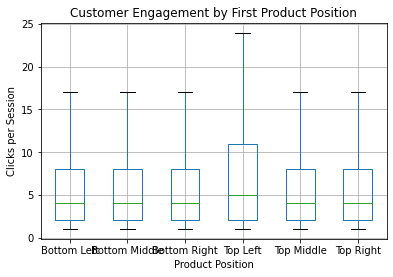

In [20]:
plt.figure(figsize=(9,6))

session_df.boxplot(
    column="click_count",
    by="first_location_name",
    showfliers=False
)

plt.title("Customer Engagement by First Product Position")
plt.suptitle("")
plt.xlabel("Product Position")
plt.ylabel("Clicks per Session")

plt.show()

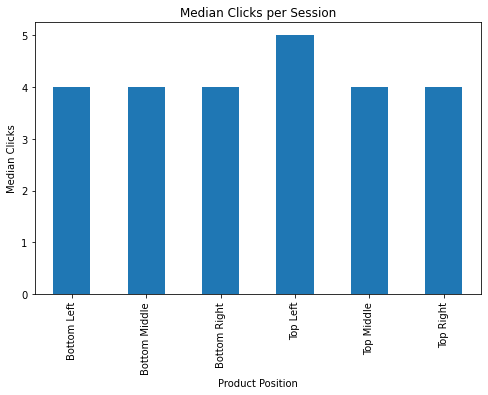

In [21]:
location_summary["median_clicks"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Median Clicks per Session")
plt.xlabel("Product Position")
plt.ylabel("Median Clicks")

plt.show()

Sessions beginning with a product located in the **Top Left** position showed noticeably higher engagement than sessions beginning from any other product position.

Top Left products had the highest mean engagement (8.54 clicks), the highest median engagement (5 clicks), and the highest upper quartile (11 clicks), while the remaining five positions displayed remarkably similar engagement distributions.

These descriptive results suggest that product position may be associated with customer browsing behaviour and warrant formal statistical testing.

In [22]:
from scipy.stats import kruskal

groups = [
    group["click_count"].values
    for _, group in session_df.groupby("first_location_name")
]

H, p_value = kruskal(*groups)

print(f"H statistic: {H:.3f}")
print(f"P-value: {p_value:.6f}")

H statistic: 227.478
P-value: 0.000000


Interpretation

There is strong statistical evidence that customer engagement differs across at least one of the six product positions.

However, the Kruskal–Wallis test does not tell us which positions differ. It only tells us that at least one difference exists.

In [23]:
# Calculate the Effect Size (ε²)
# Number of groups
k = session_df["first_location_name"].nunique()

# Total number of observations
n = len(session_df)

# Epsilon-squared
epsilon_squared = (H - k + 1) / (n - k)

print(f"Epsilon-squared: {epsilon_squared:.4f}")

Epsilon-squared: 0.0093


How much of the variation in engagement is associated with product position?

### Statistical Results

The Kruskal–Wallis test indicated a statistically significant difference in customer engagement across the six initial product positions (H = 227.48, p < 0.001).

The estimated effect size was ε² = 0.0093, indicating that product position explains only a small proportion of the overall variability in engagement.

While the descriptive statistics suggested that products first viewed in the Top Left position received higher engagement than those in other positions, the overall effect across all positions was small.

These findings suggest that product position is associated with customer engagement, but the practical magnitude of this association is limited.

In [24]:
## Dunn's test
import scikit_posthocs as sp

dunn_results = sp.posthoc_dunn(
    session_df,
    val_col="click_count",
    group_col="first_location_name",
    p_adjust="holm"
)

dunn_results.round(4)

,Bottom Left,Bottom Middle,Bottom Right,Top Left,Top Middle,Top Right
Bottom Left,1.0000,0.1130,1.0000,0.0,0.0336,0.0259
Bottom Middle,0.1130,1.0000,0.8386,0.0,1.0000,1.0000
Bottom Right,1.0000,0.8386,1.0000,0.0,0.5061,0.2927
Top Left,0.0000,0.0000,0.0000,1.0,0.0000,0.0000
Top Middle,0.0336,1.0000,0.5061,0.0,1.0000,1.0000
Top Right,0.0259,1.0000,0.2927,0.0,1.0000,1.0000


Top Left is significantly different from every other position.

4. Business Question

Are customers more engaged when their first viewed product belongs to the premium price category?

In [3]:
session_df["first_price_category_name"].value_counts(dropna=False)

yes    12129
no     11897
Name: first_price_category_name, dtype: int64

In [4]:
session_df[
    ["first_price_category", "first_price_category_name"]
].drop_duplicates().sort_values("first_price_category")

,first_price_category,first_price_category_name
1,1,yes
0,2,no


In [5]:
price_df = session_df[
    [
        "session_id",
        "click_count",
        "first_price_category",
        "first_price_category_name"
    ]
].dropna().copy()

In [6]:
print(f"Number of sessions included: {len(price_df):,}")

Number of sessions included: 24,026


In [7]:
#Descriptive statistics

price_summary = (
    price_df
    .groupby("first_price_category_name")
    .agg(
        sessions=("session_id", "count"),
        mean_clicks=("click_count", "mean"),
        median_clicks=("click_count", "median"),
        q1_clicks=("click_count", lambda x: x.quantile(0.25)),
        q3_clicks=("click_count", lambda x: x.quantile(0.75)),
        min_clicks=("click_count", "min"),
        max_clicks=("click_count", "max")
    )
    .sort_values("median_clicks", ascending=False)
)

price_summary.round(2)

,sessions,mean_clicks,median_clicks,q1_clicks,q3_clicks,min_clicks,max_clicks
first_price_category_name,,,,,,,
no,11897,7.22,4.0,2.0,9.0,1,195
yes,12129,6.56,4.0,2.0,8.0,1,192


<Figure size 576x432 with 0 Axes>

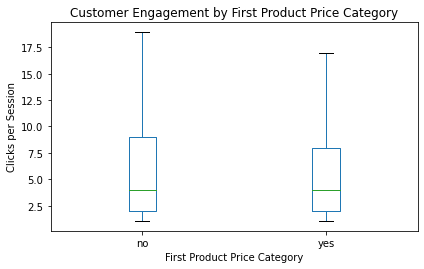

In [8]:
#Boxplot

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

price_df.boxplot(
    column="click_count",
    by="first_price_category_name",
    showfliers=False,
    grid=False
)

plt.title("Customer Engagement by First Product Price Category")
plt.suptitle("")
plt.xlabel("First Product Price Category")
plt.ylabel("Clicks per Session")
plt.tight_layout()
plt.show()

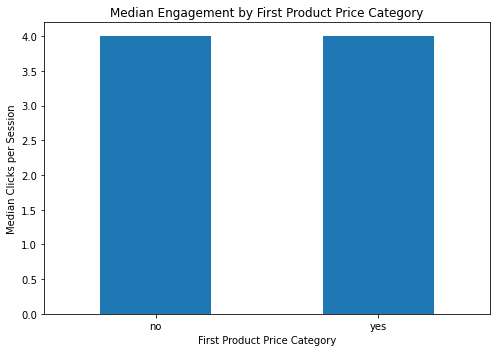

In [19]:
# Median bar chart
median_clicks = (
    price_df
    .groupby("first_price_category_name")["click_count"]
    .median()
    .sort_values(ascending=False)
)

median_clicks.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Median Engagement by First Product Price Category")
plt.xlabel("First Product Price Category")
plt.ylabel("Median Clicks per Session")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
price_df["first_price_category_name"].unique()

array(['no', 'yes'], dtype=object)

In [31]:
yes = price_df.loc[
    price_df["first_price_category_name"] == "yes",
    "click_count"
]

no = price_df.loc[
    price_df["first_price_category_name"] == "no",
    "click_count"
]

print(f"Premium sessions: {len(yes):,}")
print(f"Non-premium sessions: {len(no):,}")

Premium sessions: 12,129
Non-premium sessions: 11,897


In [32]:
group_names = price_df[
    "first_price_category_name"
].dropna().unique()

print(group_names)

['no' 'yes']


Mann–Whitney U test
Hypotheses

Null hypothesis:

The engagement distributions are the same for the two first-product price categories.

Alternative hypothesis:

The engagement distributions differ between the two first-product price categories.

In [33]:
from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(
    yes,
    no,
    alternative="two-sided"
)

print(f"U statistic: {u_stat:,.0f}")
print(f"P-value: {p_value:.6f}")

U statistic: 69,905,411
P-value: 0.000026


In [36]:
# Rank-biserial correlation

n_yes = len(premium)
n_no = len(non_premium)

rank_biserial = (
    2 * u_stat / (n_yes * n_no)
) - 1

print(
    f"Rank-biserial correlation: "
    f"{rank_biserial:.4f}"
)

Rank-biserial correlation: -0.0311


Statistical Results

The Mann–Whitney U test indicated a statistically significant difference in customer engagement between the two first-product price categories (U = 69,905,411, p < 0.001).

However, the rank-biserial correlation (r = -0.031) indicated a negligible effect size. Descriptive statistics also showed nearly identical medians and highly overlapping distributions.

These findings suggest that although engagement differs statistically between price categories, the practical magnitude of the association is very small.